In [1]:
import numpy as np
import matplotlib.pyplot as plt

from analytics_arxiv_2511_17083 import functions, parameters, expressions

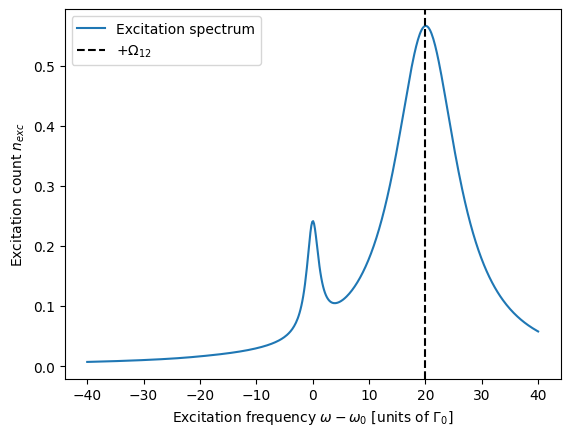

In [2]:
# evaluate an analytical expression for a given set of parameters.
params = {
    "omega_0" : 0,
    "omega" : np.linspace(-40, 40, 500),
    "Gamma_0": 1,
    "Omega_R": 5,
    "Omega_12": 20,
    "gamma_12": 0.3,
    "gamma_d": 1,
}

# function is a dict of python functions, one for each density matrix element
# and one for the total excitation count n_exc = rho_ee,ee + rho_eg,eg
spectrum = functions["excitation_number"](**params)


fig, ax = plt.subplots()
ax.plot(params["omega"], spectrum, label="Excitation spectrum")
ax.set_xlabel(r"Excitation frequency $\omega-\omega_0$ [units of $\Gamma_0$]")
ax.axvline(params["Omega_12"], c="k", linestyle="--", label=r"$+\Omega_{12}$")
ax.set_ylabel(r"Excitation count $n_{exc}$")
_ = ax.legend()

In [3]:
# Print an analytical expression for the spectrum in the gamma^* = 0 case
# without dephasing, the exact expressions are usually manageable by hand
n_exc = expressions["excitation_number"].subs([
    (parameters["omega_0"], 0),
    (parameters["gamma_d"], 0)
]).simplify()
n_exc

2*Omega_R**2*(Gamma_0**2 + 2*Omega_R**2 + 4*omega**2)/(Gamma_0**4 + 2*Gamma_0**3*gamma_12 + 4*Gamma_0**2*Omega_12**2 - 8*Gamma_0**2*Omega_12*omega + 4*Gamma_0**2*Omega_R**2 + Gamma_0**2*gamma_12**2 + 8*Gamma_0**2*omega**2 + 8*Gamma_0*gamma_12*omega**2 + 16*Omega_12**2*omega**2 - 32*Omega_12*omega**3 + 4*Omega_R**4 + 16*Omega_R**2*omega**2 + 4*gamma_12**2*omega**2 + 16*omega**4)

In [4]:
# Print an analytical expression for the spectrum in the gamma^* != 0 case
# The exact expressions are too long, so we take series expansions, for instance for small Rabi frequency

# expressions["excitation_number"]     # too long !

# here the expression factorizes as 2 * Omega_R ** 2 * (1/denominator) * numerator 
two, omega_R_2, inv_denominator, numerator = expressions["excitation_number"].subs(parameters["omega_0"], 0).factor().args
# to get our 1st order expansion in Omega_R^2 (the zeroth order is null)
# we can set Omega_R = 0 in the numerator and denominator 
inv_denominator = inv_denominator.subs(parameters["Omega_R"], 0)
numerator = numerator.subs(parameters["Omega_R"], 0)

n_exc_1st_order = two * omega_R_2 * numerator.factor() * inv_denominator.factor()
n_exc_1st_order    # much more manageable !

2*Omega_R**2*(Gamma_0 - gamma_12 + gamma_d)*(Gamma_0 + gamma_12 + gamma_d)/((Gamma_0**2 + Gamma_0*gamma_d - gamma_12**2)*(Gamma_0**2 + 2*Gamma_0*gamma_12 + 2*Gamma_0*gamma_d + 4*Omega_12**2 - 8*Omega_12*omega + gamma_12**2 + 2*gamma_12*gamma_d + gamma_d**2 + 4*omega**2))